# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [17]:
# Replace None with your code
# Imports
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots readable and professional
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Create connection to database
# The first path works in the official lab repo; the second works for this submitted copy.
data_path_options = [Path("data.sqlite"), Path("data(2).sqlite"), Path("../data.sqlite")]
data_path = next((path for path in data_path_options if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("Could not find data.sqlite. Make sure the database is in the same folder as this notebook.")

conn = sqlite3.connect(data_path)

# Quick check that the connection points to the expected database
pd.read_sql("""
SELECT name AS table_name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
""", conn)



,table_name
0,customers
1,employees
2,offices
3,orderdetails
4,orders
5,payments
6,productlines
7,products


### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.
*Hint*: Make sure creditLimit is numeric.

In [18]:
# Replace None with your code
california_high_credit_df = pd.read_sql("""
SELECT
    customerNumber,
    customerName,
    contactFirstName,
    contactLastName,
    city,
    state,
    country,
    CAST(creditLimit AS REAL) AS creditLimit
FROM customers
WHERE state = 'CA'
  AND CAST(creditLimit AS REAL) > 25000
ORDER BY creditLimit DESC;
""", conn)

california_high_credit_df

,customerNumber,customerName,contactFirstName,contactLastName,city,state,country,creditLimit
0,124,Mini Gifts Distributors Ltd.,Susan,Nelson,San Rafael,CA,USA,210500.0
1,239,Collectable Mini Designs Co.,Valarie,Thompson,San Diego,CA,USA,105000.0
2,321,Corporate Gift Ideas Co.,Julie,Brown,San Francisco,CA,USA,105000.0
3,205,Toys4GrownUps.com,Julie,Young,Pasadena,CA,USA,90700.0
4,161,Technics Stores Inc.,Juri,Hashimoto,Burlingame,CA,USA,84600.0
5,450,The Sharp Gifts Warehouse,Sue,Frick,San Jose,CA,USA,77600.0
6,129,Mini Wheels Co.,Julie,Murphy,San Francisco,CA,USA,64600.0
7,487,Signal Collectibles Ltd.,Sue,Taylor,Brisbane,CA,USA,60300.0
8,347,"Men 'R' US Retailers, Ltd.",Brian,Chandler,Los Angeles,CA,USA,57700.0
9,475,West Coast Collectables Co.,Steve,Thompson,Burbank,CA,USA,55400.0


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [19]:
# Replace None with your code
international_collect_df = pd.read_sql("""
SELECT
    customerNumber,
    customerName,
    contactFirstName,
    contactLastName,
    city,
    country
FROM customers
WHERE country <> 'USA'
  AND customerName LIKE '%Collect%'
ORDER BY country, customerName;
""", conn)

international_collect_df

,customerNumber,customerName,contactFirstName,contactLastName,city,country
0,471,"Australian Collectables, Ltd",Sean,Clenahan,Glen Waverly,Australia
1,114,"Australian Collectors, Co.",Peter,Ferguson,Melbourne,Australia
2,382,Salzburg Collectables,Georg,Pipps,Salzburg,Austria
3,260,"Royal Canadian Collectables, Ltd.",Elizabeth,Lincoln,Tsawassen,Canada
4,227,Heintze Collectables,Palle,Ibsen,Århus,Denmark
5,353,Reims Collectables,Paul,Henriot,Reims,France
6,415,"Bavarian Collectables Imports, Co.",Michael,Donnermeyer,Munich,Germany
7,409,Stuttgart Collectable Exchange,Rita,Müller,Stuttgart,Germany
8,211,"King Kong Collectables, Co.",Mike,Gao,Central Hong Kong,Hong Kong
9,189,"Clover Collections, Co.",Dean,Cassidy,Dublin,Ireland


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!

## Reflection Question Answer

The `WHERE` clause filters the results so that only customers who meet both requirements of the international campaign are returned. The condition `country <> 'USA'` excludes all customers located in the United States, leaving only international customers. The condition `customerName LIKE '%Collect%'` then selects only those customers whose names contain the pattern "Collect" anywhere within the customer name.

The `AND` operator ensures that both conditions must be satisfied simultaneously. As a result, a customer will only appear in the results if they are located outside the United States and their name contains the specified campaign keyword. Placing the `%` wildcard before and after `Collect` enables the database to match names such as "Collectables," "Collectors," or "Collectable," even when the pattern appears as part of a longer name.


### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [20]:
# Replace None with your code
state_credit_df = pd.read_sql("""
SELECT
    state,
    COUNT(*) AS number_of_customers,
    ROUND(AVG(CAST(creditLimit AS REAL)), 2) AS average_credit_limit
FROM customers
WHERE country = 'USA'
  AND state IS NOT NULL
  AND TRIM(state) <> ''
  AND creditLimit IS NOT NULL
GROUP BY state
ORDER BY average_credit_limit DESC;
""", conn)

state_credit_df

,state,number_of_customers,average_credit_limit
0,NH,1,114200.00
1,NY,6,89966.67
2,PA,3,84766.67
3,CA,11,83854.55
4,NV,1,71800.00
5,MA,9,70755.56
6,CT,4,57350.00
7,NJ,1,43000.00


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

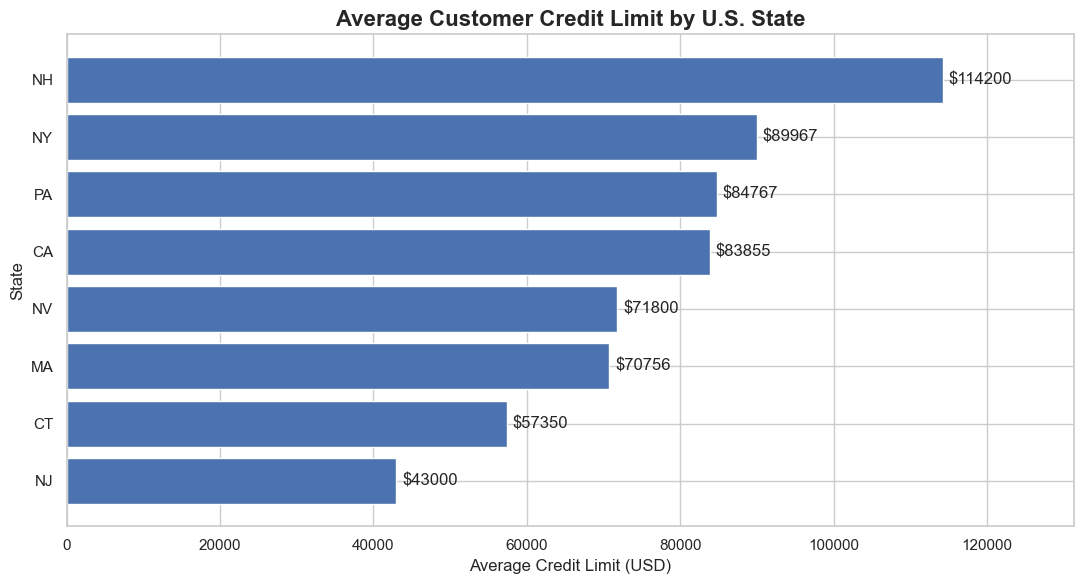

In [21]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
# Produce a visual to represent the average credit limit by state
fig, ax = plt.subplots(figsize=(11, 6))

plot_df = state_credit_df.sort_values("average_credit_limit", ascending=True)
ax.barh(plot_df["state"], plot_df["average_credit_limit"])

ax.set_title("Average Customer Credit Limit by U.S. State", fontsize=16, weight="bold")
ax.set_xlabel("Average Credit Limit (USD)", fontsize=12)
ax.set_ylabel("State", fontsize=12)
ax.bar_label(ax.containers[0], fmt="$%.0f", padding=4)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [22]:
# Replace None with your code
top_customers_df = pd.read_sql("""
SELECT
    c.customerNumber,
    c.customerName,
    ROUND(SUM(CAST(p.amount AS REAL)), 2) AS total_payments
FROM customers AS c
INNER JOIN payments AS p
    ON c.customerNumber = p.customerNumber
GROUP BY c.customerNumber, c.customerName
ORDER BY total_payments DESC
LIMIT 10;
""", conn)

top_customers_df

,customerNumber,customerName,total_payments
0,141,Euro+ Shopping Channel,715738.98
1,124,Mini Gifts Distributors Ltd.,584188.24
2,114,"Australian Collectors, Co.",180585.07
3,151,Muscle Machine Inc,177913.95
4,148,"Dragon Souveniers, Ltd.",156251.03
5,323,"Down Under Souveniers, Inc",154622.08
6,187,"AV Stores, Co.",148410.09
7,276,"Anna's Decorations, Ltd",137034.22
8,321,Corporate Gift Ideas Co.,132340.78
9,146,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

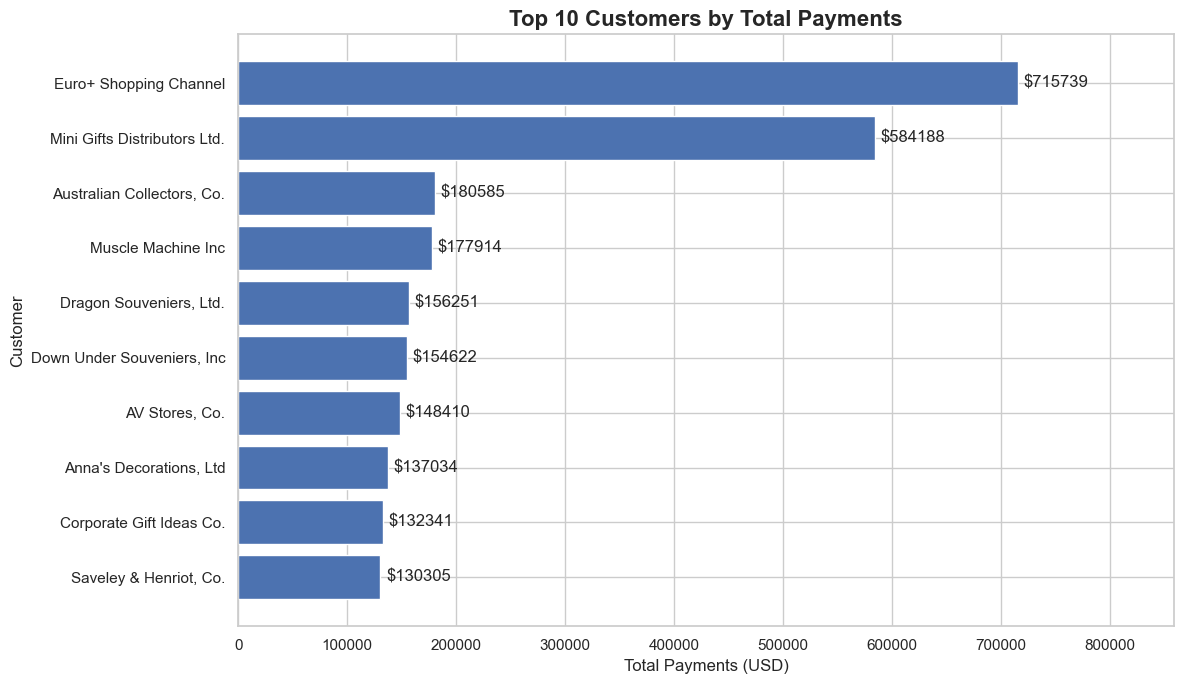

In [23]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
# Produce a visual to represent the top ten customers in terms of total payments
fig, ax = plt.subplots(figsize=(12, 7))

plot_df = top_customers_df.sort_values("total_payments", ascending=True)
ax.barh(plot_df["customerName"], plot_df["total_payments"])

ax.set_title("Top 10 Customers by Total Payments", fontsize=16, weight="bold")
ax.set_xlabel("Total Payments (USD)", fontsize=12)
ax.set_ylabel("Customer", fontsize=12)
ax.bar_label(ax.containers[0], fmt="$%.0f", padding=4)
ax.margins(x=0.2)
plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [24]:
# Replace None with you code
customer_product_quantities_df = pd.read_sql("""
SELECT
    c.customerNumber,
    c.customerName,
    p.productCode,
    p.productName,
    p.productLine,
    SUM(CAST(od.quantityOrdered AS INTEGER)) AS total_quantity_purchased
FROM customers AS c
INNER JOIN orders AS o
    ON c.customerNumber = o.customerNumber
INNER JOIN orderdetails AS od
    ON o.orderNumber = od.orderNumber
INNER JOIN products AS p
    ON od.productCode = p.productCode
GROUP BY
    c.customerNumber,
    c.customerName,
    p.productCode,
    p.productName,
    p.productLine
HAVING total_quantity_purchased >= 10
ORDER BY total_quantity_purchased ASC;
""", conn)

customer_product_quantities_df

,customerNumber,customerName,productCode,productName,productLine,total_quantity_purchased
0,314,Petit Auto,S18_2949,1913 Ford Model T Speedster,Vintage Cars,10
1,412,"Extreme Desk Decorations, Ltd",S24_4620,1961 Chevrolet Impala,Classic Cars,10
2,119,La Rochelle Gifts,S32_2509,1954 Greyhound Scenicruiser,Trucks and Buses,11
3,328,Tekni Collectables Inc.,S700_1691,American Airlines: B767-300,Planes,11
4,450,The Sharp Gifts Warehouse,S24_3191,1969 Chevrolet Camaro Z28,Classic Cars,13
...,...,...,...,...,...,...
2526,141,Euro+ Shopping Channel,S24_3432,2002 Chevy Corvette,Classic Cars,174
2527,141,Euro+ Shopping Channel,S12_4473,1957 Chevy Pickup,Trucks and Buses,183
2528,141,Euro+ Shopping Channel,S24_1444,1970 Dodge Coronet,Classic Cars,197
2529,141,Euro+ Shopping Channel,S24_2840,1958 Chevy Corvette Limited Edition,Classic Cars,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [25]:
# Replace None with your code
product_line_analysis_df = pd.read_sql("""
SELECT
    p.productLine,
    COUNT(DISTINCT p.productCode) AS number_of_products,
    SUM(CAST(od.quantityOrdered AS INTEGER)) AS total_quantity_ordered
FROM products AS p
INNER JOIN orderdetails AS od
    ON p.productCode = od.productCode
GROUP BY p.productLine
ORDER BY total_quantity_ordered DESC;
""", conn)

product_line_analysis_df


,productLine,number_of_products,total_quantity_ordered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

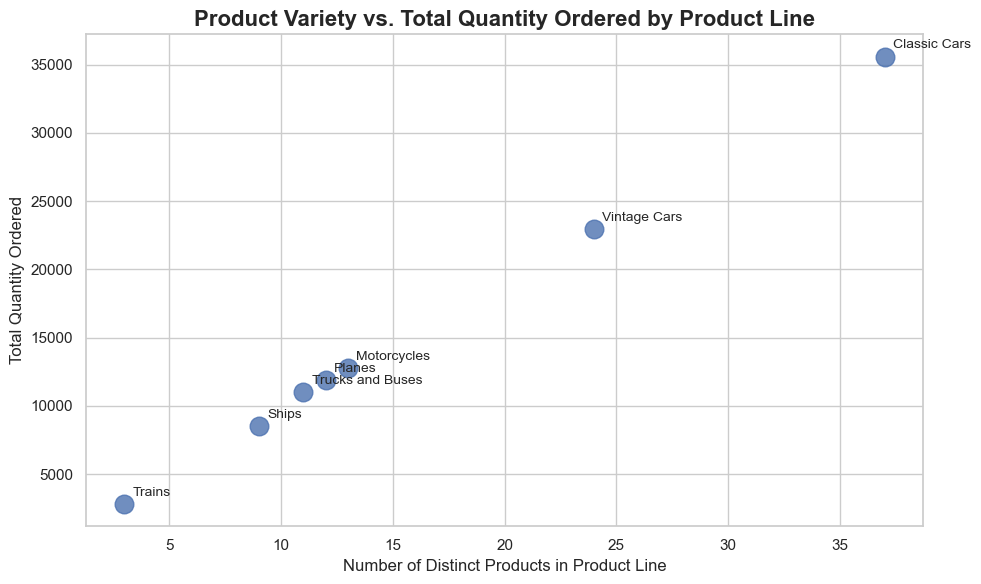

In [26]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
# Produce a visual to represent the relation between number of products and total amount ordered
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    product_line_analysis_df["number_of_products"],
    product_line_analysis_df["total_quantity_ordered"],
    s=180,
    alpha=0.8
)

for _, row in product_line_analysis_df.iterrows():
    ax.annotate(
        row["productLine"],
        (row["number_of_products"], row["total_quantity_ordered"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10
    )

ax.set_title("Product Variety vs. Total Quantity Ordered by Product Line", fontsize=16, weight="bold")
ax.set_xlabel("Number of Distinct Products in Product Line", fontsize=12)
ax.set_ylabel("Total Quantity Ordered", fontsize=12)
plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!

## Reflection Question Answer

I selected a scatter plot because the business question focuses on identifying whether a relationship exists between two numerical variables: the number of products within each product line and the total quantity ordered for that product line. A scatter plot is appropriate because each point represents a product line, making it easier to observe whether product lines with a greater number of products also tend to generate higher order quantities.

From a business perspective, this visualization allows the product team to compare product variety with customer demand. The chart indicates that product lines offering more unique products, particularly Classic Cars and Vintage Cars, generally have higher total quantities ordered. This suggests that a wider product selection may be associated with increased demand. However, factors such as product popularity, pricing, and customer preferences should also be evaluated before making inventory decisions.


### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [27]:
# Replace None with your code
remote_office_employees_df = pd.read_sql("""
SELECT
    e.employeeNumber,
    e.firstName || ' ' || e.lastName AS employeeName,
    e.jobTitle,
    e.email,
    e.officeCode,
    o.city AS officeCity,
    o.country AS officeCountry,
    e.reportsTo AS supervisorEmployeeNumber,
    m.firstName || ' ' || m.lastName AS supervisorName
FROM employees AS e
INNER JOIN offices AS o
    ON e.officeCode = o.officeCode
LEFT JOIN employees AS m
    ON e.reportsTo = m.employeeNumber
WHERE e.officeCode IN (
    SELECT officeCode
    FROM employees
    GROUP BY officeCode
    HAVING COUNT(*) < 5
)
ORDER BY e.officeCode, employeeName;
""", conn)

remote_office_employees_df

,employeeNumber,employeeName,jobTitle,email,officeCode,officeCity,officeCountry,supervisorEmployeeNumber,supervisorName
0,1188,Julie Firrelli,Sales Rep,jfirrelli@classicmodelcars.com,2,Boston,USA,1143,Anthony Bow
1,1216,Steve Patterson,Sales Rep,spatterson@classicmodelcars.com,2,Boston,USA,1143,Anthony Bow
2,1286,Foon Yue Tseng,Sales Rep,ftseng@classicmodelcars.com,3,NYC,USA,1143,Anthony Bow
3,1323,George Vanauf,Sales Rep,gvanauf@classicmodelcars.com,3,NYC,USA,1143,Anthony Bow
4,1621,Mami Nishi,Sales Rep,mnishi@classicmodelcars.com,5,Tokyo,Japan,1056,Mary Patterson
5,1625,Yoshimi Kato,Sales Rep,ykato@classicmodelcars.com,5,Tokyo,Japan,1621,Mami Nishi
6,1611,Andy Fixter,Sales Rep,afixter@classicmodelcars.com,6,Sydney,Australia,1088,William Patterson
7,1612,Peter Marsh,Sales Rep,pmarsh@classicmodelcars.com,6,Sydney,Australia,1088,William Patterson
8,1619,Tom King,Sales Rep,tking@classicmodelcars.com,6,Sydney,Australia,1088,William Patterson
9,1088,William Patterson,Sales Manager (APAC),wpatterson@classicmodelcars.com,6,Sydney,Australia,1056,Mary Patterson


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!

## Reflection Question Answer

I used a subquery to identify offices with fewer than five employees. The subquery groups records in the `employees` table by `officeCode` and applies `HAVING COUNT(*) < 5` to return only the office codes that satisfy the small-office requirement. The `HAVING` clause is appropriate here because the filtering is based on an aggregated count rather than an individual row value.

The main query then uses those office codes in the `WHERE e.officeCode IN (...)` condition to retrieve detailed information about employees working in those smaller offices. I joined the `employees` table with the `offices` table to include each employee's office location, and I also performed a self-join on the `employees` table to display each employee's supervisor's name. This provides management with valuable information about employees, their job titles, office locations, and reporting relationships, making the results useful for planning remote work support.


### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [28]:
# Replace None with your code
conn.close()
print("Connection to data.sqlite closed successfully.")

Connection to data.sqlite closed successfully.


### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [29]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

,start_year,number_of_rated_movies,average_rating,total_votes
0,2010,6038,6.27,30451629
1,2011,6542,6.29,32705303
2,2012,6866,6.29,32690541
3,2013,7216,6.29,35602189
4,2014,7528,6.32,34349175
5,2015,7650,6.27,26130902
6,2016,7785,6.33,26582689
7,2017,7718,6.36,21863473
8,2018,6573,6.38,16465411
9,2019,1804,6.65,3059853


,genre,movie_count,average_rating,vote_weighted_rating,total_votes,average_runtime_minutes
0,Western,45,6.14,7.55,2423275,105.3
1,Biography,701,6.96,7.48,21281443,112.2
2,History,387,6.89,7.38,7583257,115.2
3,Documentary,741,7.27,7.35,3574276,96.3
4,Sport,196,6.93,7.32,3620344,107.7
5,Animation,376,6.68,7.28,15156639,93.1
6,Sci-Fi,533,5.71,7.14,42696791,102.4
7,Music,283,6.75,7.14,5258924,107.2
8,War,163,6.72,7.13,2579280,113.2
9,Musical,70,6.54,7.11,1319990,120.0


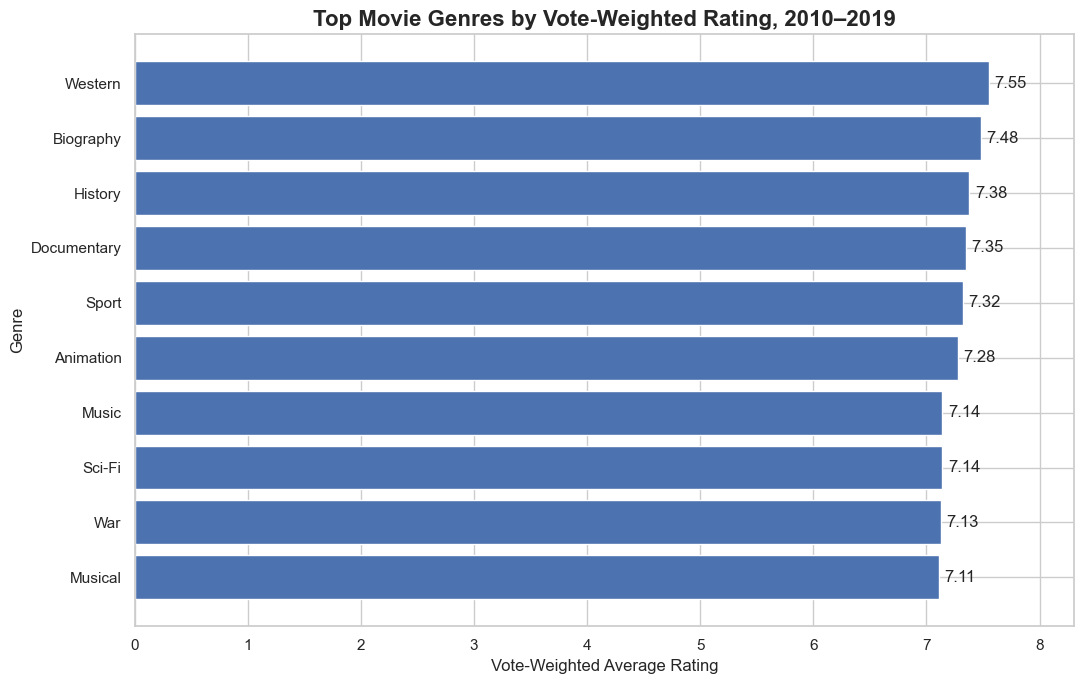

,runtime_band,movie_count,average_rating,vote_weighted_rating,total_votes
0,150+ min,417,6.99,7.68,16770998
1,120-149 min,1581,6.76,7.29,79669636
2,100-119 min,3129,6.44,6.82,100014560
3,80-99 min,4187,5.85,6.37,55033922
4,Under 80 min,293,6.20,6.30,1003142


Initial Exploration Summary
- The valid rated movie data spans 2010 through 2019 after excluding nulls and inaccurate post-2019 records.
- Genre strings must be normalized because each movie can contain multiple comma-separated genres.
- Among genres with at least 25 sufficiently-voted movies, the strongest genres by vote-weighted rating appear at the top of genre_performance_df.
- Runtime bands show that audience engagement and ratings vary by movie length, making runtime useful for deeper analysis.

Business Question
Which genres and runtime ranges provide the strongest audience engagement, measured by vote-weighted rating and total votes, for movies released from 2010 to 2019?

Potential Data Cleaning Tasks
- Exclude movies released after 2019 because the lab notes say those records are not current or accurate.
- Exclude null values in key fields such as start_year, runtime_minutes, genres, averagerating, and numvotes.
- Normalize the comma-separated genres column into a separate ge

In [30]:
# Begin your code here
# Part 2: Exploratory Analysis with SQL
# Reconnect to the movie database in case this cell is run independently.
conn4 = sqlite3.connect("im.db")

# 1) Initial exploration: valid rated movies by release year.
movies_by_year_df = pd.read_sql("""
SELECT
    mb.start_year,
    COUNT(DISTINCT mb.movie_id) AS number_of_rated_movies,
    ROUND(AVG(mr.averagerating), 2) AS average_rating,
    SUM(mr.numvotes) AS total_votes
FROM movie_basics AS mb
INNER JOIN movie_ratings AS mr
    ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
  AND mb.start_year IS NOT NULL
  AND mb.runtime_minutes IS NOT NULL
  AND mb.genres IS NOT NULL
  AND mr.averagerating IS NOT NULL
  AND mr.numvotes IS NOT NULL
GROUP BY mb.start_year
ORDER BY mb.start_year;
""", conn4)

display(movies_by_year_df)

# 2) Genre-level exploration.
# Genres are stored as comma-separated strings, so this recursive CTE normalizes them into one genre per row.
genre_performance_df = pd.read_sql("""
WITH RECURSIVE split_genres AS (
    SELECT
        mb.movie_id,
        mb.primary_title,
        mb.start_year,
        mb.runtime_minutes,
        mr.averagerating,
        mr.numvotes,
        mb.genres || ',' AS remaining_genres,
        '' AS genre
    FROM movie_basics AS mb
    INNER JOIN movie_ratings AS mr
        ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mb.runtime_minutes IS NOT NULL
      AND mb.genres IS NOT NULL
      AND mr.averagerating IS NOT NULL
      AND mr.numvotes IS NOT NULL
      AND mr.numvotes >= 1000

    UNION ALL

    SELECT
        movie_id,
        primary_title,
        start_year,
        runtime_minutes,
        averagerating,
        numvotes,
        SUBSTR(remaining_genres, INSTR(remaining_genres, ',') + 1),
        TRIM(SUBSTR(remaining_genres, 1, INSTR(remaining_genres, ',') - 1))
    FROM split_genres
    WHERE remaining_genres <> ''
)
SELECT
    genre,
    COUNT(DISTINCT movie_id) AS movie_count,
    ROUND(AVG(averagerating), 2) AS average_rating,
    ROUND(SUM(averagerating * numvotes) / SUM(numvotes), 2) AS vote_weighted_rating,
    SUM(numvotes) AS total_votes,
    ROUND(AVG(runtime_minutes), 1) AS average_runtime_minutes
FROM split_genres
WHERE genre <> ''
GROUP BY genre
HAVING movie_count >= 25
ORDER BY vote_weighted_rating DESC, total_votes DESC;
""", conn4)

display(genre_performance_df)
# Visual for slide presentation: strongest genres by vote-weighted rating.
top_genres_for_visual = genre_performance_df.head(10).sort_values("vote_weighted_rating", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_genres_for_visual["genre"], top_genres_for_visual["vote_weighted_rating"])
ax.set_title("Top Movie Genres by Vote-Weighted Rating, 2010–2019", fontsize=16, weight="bold")
ax.set_xlabel("Vote-Weighted Average Rating", fontsize=12)
ax.set_ylabel("Genre", fontsize=12)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=4)
ax.margins(x=0.1)
plt.tight_layout()
plt.savefig("part2_top_genres_weighted_rating.png", dpi=160, bbox_inches="tight")
plt.show()

# 3) Runtime and rating relationship for a deeper business question.
runtime_rating_df = pd.read_sql("""
SELECT
    CASE
        WHEN mb.runtime_minutes < 80 THEN 'Under 80 min'
        WHEN mb.runtime_minutes BETWEEN 80 AND 99 THEN '80-99 min'
        WHEN mb.runtime_minutes BETWEEN 100 AND 119 THEN '100-119 min'
        WHEN mb.runtime_minutes BETWEEN 120 AND 149 THEN '120-149 min'
        ELSE '150+ min'
    END AS runtime_band,
    COUNT(DISTINCT mb.movie_id) AS movie_count,
    ROUND(AVG(mr.averagerating), 2) AS average_rating,
    ROUND(SUM(mr.averagerating * mr.numvotes) / SUM(mr.numvotes), 2) AS vote_weighted_rating,
    SUM(mr.numvotes) AS total_votes
FROM movie_basics AS mb
INNER JOIN movie_ratings AS mr
    ON mb.movie_id = mr.movie_id
WHERE mb.start_year BETWEEN 2010 AND 2019
  AND mb.runtime_minutes IS NOT NULL
  AND mb.genres IS NOT NULL
  AND mr.averagerating IS NOT NULL
  AND mr.numvotes IS NOT NULL
  AND mr.numvotes >= 1000
GROUP BY runtime_band
ORDER BY vote_weighted_rating DESC;
""", conn4)

display(runtime_rating_df)

# Store concise findings for the presentation.
print("Initial Exploration Summary")
print("- The valid rated movie data spans 2010 through 2019 after excluding nulls and inaccurate post-2019 records.")
print("- Genre strings must be normalized because each movie can contain multiple comma-separated genres.")
print("- Among genres with at least 25 sufficiently-voted movies, the strongest genres by vote-weighted rating appear at the top of genre_performance_df.")
print("- Runtime bands show that audience engagement and ratings vary by movie length, making runtime useful for deeper analysis.")

print("\nBusiness Question")
print("Which genres and runtime ranges provide the strongest audience engagement, measured by vote-weighted rating and total votes, for movies released from 2010 to 2019?")

print("\nPotential Data Cleaning Tasks")
print("- Exclude movies released after 2019 because the lab notes say those records are not current or accurate.")
print("- Exclude null values in key fields such as start_year, runtime_minutes, genres, averagerating, and numvotes.")
print("- Normalize the comma-separated genres column into a separate genre mapping table for cleaner analysis.")
print("- Watch for duplicate movie rows when joining to multi-row tables such as directors, writers, principals, and movie_akas.")
print("- Standardize text categories such as genres, regions, languages, and person roles before deeper analysis.")
print("- Investigate extreme or unrealistic runtime values before using runtime in final modeling or recommendations.")

conn4.close()

## Part 2 Summary and Interpretation

My exploratory analysis examines rated movies released between 2010 and 2019, excluding records with null values in the fields needed for the analysis. Since the dataset includes important multi-valued fields, particularly `genres`, I normalized the comma-separated genre entries in SQL before generating genre-level summaries. This approach prevents combinations such as `Action,Adventure,Sci-Fi` from being treated as a single genre, making the analysis more accurate and easier to interpret.

The genre analysis evaluates each genre based on movie count, average rating, vote-weighted rating, total votes, and average runtime. I chose the vote-weighted rating because it places greater emphasis on ratings backed by a larger number of audience votes. This metric is more appropriate for business decision-making than a simple average rating, as it avoids giving the same importance to genres with only a few lightly voted movies as those with substantial audience engagement.


## Part 2 Business Question

**Business Question:** Which genres and runtime ranges generate the highest audience engagement, based on vote-weighted ratings and total votes, for movies released between 2010 and 2019?

This question is important because movie studios and streaming platforms must determine the types of content that are most likely to appeal to and engage audiences. Genres with high vote-weighted ratings and large numbers of votes indicate both strong viewer satisfaction and broad audience appeal. Analyzing runtime ranges also provides valuable production insights, as movie length influences production costs, scheduling, audience attention, and content recommendation strategies.


## Part 2 Cleaning Assessment

Before using this data for deeper analysis, I would clean it by excluding movies after 2019, removing null values from key analytical fields, and normalizing the comma-separated `genres` column into a separate movie-to-genre table. I would also check for duplicate rows after joins because tables such as `directors`, `writers`, `principals`, and `movie_akas` can contain multiple rows for the same movie.

Additional cleaning tasks would include standardizing text fields such as language, region, category, and role values; reviewing unusually short or unusually long runtimes; and confirming that rating and vote values are valid numeric values. These tasks are important because clean and properly structured data reduces misleading counts, prevents duplicate-driven aggregation errors, and makes the final insights more reliable for business decisions.